# W&T Sales Associate Revenue — Preliminary Analysis

**Goal:** Attribute sales revenue to each sales associate by correlating the
**first two characters of the `Batch Number`** to the W&T roster, then quantify
the revenue contributed by each **active** member.

This is the *first preliminary step* toward a sales-associate evaluation
(modeled loosely on the existing `coreline_sales_associates_evaluation`
project). It establishes the data foundation and a first revenue read — it is
**not** yet a full scoring engine.

### Method & decisions
1. **Attribution** — match `Batch Number[:2]` to roster `Batch Initial`.
   Free-text batch variants (`MORGANW`, `TINAN`, `VANESSAW`) are matched against
   the roster `Other Names` column and folded into the correct active associate.
   Everything else (`AC`, `JL`, `KS`, `SL`, `YU`, `DO NOT POST`, …) is treated as
   **Unmatched/Other** — excluded from associate revenue but reported separately.
2. **Returns ignored** — only `SOP Type == "Invoice"` rows are counted.
3. **Period** — combined 2-year total **and** a by-year split (FY24–25 vs FY25–26).
4. **Revenue metric** — sum of `Extended Price` (item-level extended revenue).

## 1. Imports & configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

ROSTER_PATH = "w&t_sales_associate_roster.xlsx"

# Each sales file corresponds to one fiscal year (June–June).
SALES_FILES = {
    "FY24-25": "sales_data/June 2024- June 2025.XLSX",
    "FY25-26": "sales_data/June 2025-June 2026.XLSX",
}

REVENUE_COL = "Extended Price"

## 2. Load & normalize the roster

The roster maps a 2-letter `Batch Initial` to a `Sales Person Name` and a
`Status` (Active/Inactive). `Other Names` holds free-text batch variants.

In [2]:
roster = pd.read_excel(ROSTER_PATH)

# Normalize text columns: strip whitespace, upper-case the codes/variants.
roster["Batch Initial"] = roster["Batch Initial"].astype(str).str.strip().str.upper()
roster["Other Names"] = roster["Other Names"].astype(str).str.strip().str.upper()
roster.loc[roster["Other Names"].isin(["", "NAN"]), "Other Names"] = np.nan
roster["Sales Person Name"] = roster["Sales Person Name"].astype(str).str.strip()
roster.loc[roster["Sales Person Name"].isin(["", "nan"]), "Sales Person Name"] = np.nan
roster["Status"] = roster["Status"].astype(str).str.strip().str.title()

roster

,Batch Initial,Sales Person Name,Other Names,Status
0,GM,Garmi Mei,NaN,Active
1,CC,Cindy Chan,NaN,Active
2,MW,Morgan Wu,MORGANW,Active
3,YT,Ting Ting,NaN,Active
4,YC,Wendy Ye,NaN,Active
5,AN,An Cao,NaN,Active
6,TN,Tina Ni,TINAN,Active
7,MT,NaN,NaN,Inactive
8,PJ,NaN,NaN,Inactive
9,VW,Vanessa Wu,VANESSAW,Active


In [3]:
# Build two lookup dictionaries used by the attribution helper.
#  - prefix_map:  2-letter Batch Initial -> {name, status}
#  - othername_map: full free-text batch string -> {name, status}
prefix_map = {
    r["Batch Initial"]: {"name": r["Sales Person Name"], "status": r["Status"]}
    for _, r in roster.iterrows()
}
othername_map = {
    r["Other Names"]: {"name": r["Sales Person Name"], "status": r["Status"]}
    for _, r in roster.iterrows()
    if pd.notna(r["Other Names"])
}

print("Prefix map:", prefix_map)
print("\nOther-names map:", othername_map)
active_names = sorted(roster.loc[roster["Status"] == "Active", "Sales Person Name"].dropna())
print(f"\n{len(active_names)} active associates:", active_names)

Prefix map: {'GM': {'name': 'Garmi Mei', 'status': 'Active'}, 'CC': {'name': 'Cindy Chan', 'status': 'Active'}, 'MW': {'name': 'Morgan Wu', 'status': 'Active'}, 'YT': {'name': 'Ting Ting', 'status': 'Active'}, 'YC': {'name': 'Wendy Ye', 'status': 'Active'}, 'AN': {'name': 'An Cao', 'status': 'Active'}, 'TN': {'name': 'Tina Ni', 'status': 'Active'}, 'MT': {'name': nan, 'status': 'Inactive'}, 'PJ': {'name': nan, 'status': 'Inactive'}, 'VW': {'name': 'Vanessa Wu', 'status': 'Active'}}

Other-names map: {'MORGANW': {'name': 'Morgan Wu', 'status': 'Active'}, 'TINAN': {'name': 'Tina Ni', 'status': 'Active'}, 'VANESSAW': {'name': 'Vanessa Wu', 'status': 'Active'}}

8 active associates: ['An Cao', 'Cindy Chan', 'Garmi Mei', 'Morgan Wu', 'Tina Ni', 'Ting Ting', 'Vanessa Wu', 'Wendy Ye']


## 3. Load the sales data

Both item-level files are loaded and tagged with their fiscal year, then
concatenated into a single frame.

In [4]:
frames = []
for fy, path in SALES_FILES.items():
    d = pd.read_excel(path)
    d["Fiscal Year"] = fy
    frames.append(d)
    print(f"{fy}: {len(d):,} rows  ({path})")

sales_raw = pd.concat(frames, ignore_index=True)
print(f"\nCombined: {len(sales_raw):,} item-level rows")
print("Columns:", list(sales_raw.columns))

FY24-25: 62,989 rows  (sales_data/June 2024- June 2025.XLSX)


FY25-26: 60,554 rows  (sales_data/June 2025-June 2026.XLSX)

Combined: 123,543 item-level rows
Columns: ['SOP Type', 'SOP Number', 'Item Number', 'Item Description', 'QTY', 'Extended Price', 'Unit Price', 'Customer Number', 'Extended Cost', 'Document Date', 'Unit Cost', 'Customer Name', 'Customer Type', 'Batch Number', 'Fiscal Year']


## 4. Clean & filter

Keep only **Invoice** rows (returns ignored per the agreed method), coerce the
revenue column to numeric, and normalize the batch string.

In [5]:
print("SOP Type breakdown (all rows):")
print(sales_raw["SOP Type"].value_counts(dropna=False))

sales = sales_raw[sales_raw["SOP Type"] == "Invoice"].copy()

sales[REVENUE_COL] = pd.to_numeric(sales[REVENUE_COL], errors="coerce")
sales["Batch Number"] = sales["Batch Number"].astype(str).str.strip().str.upper()

# Drop rows with no usable batch or no revenue.
before = len(sales)
sales = sales[~sales["Batch Number"].isin(["", "NAN"])]
sales = sales[sales[REVENUE_COL].notna()]
print(f"\nInvoice rows: {before:,} -> {len(sales):,} after dropping blank batch / null revenue")
print(f"Total invoice revenue (Extended Price): ${sales[REVENUE_COL].sum():,.2f}")

SOP Type breakdown (all rows):
SOP Type
Invoice    123429
Return        114
Name: count, dtype: int64

Invoice rows: 123,429 -> 123,429 after dropping blank batch / null revenue
Total invoice revenue (Extended Price): $60,694,520.51


## 5. Attribution: batch number → sales associate

A single reusable helper resolves each batch string to an associate so the same
logic can be imported by later notebooks / app code.

Resolution order:
1. **Exact `Other Names` match** (free-text variants like `MORGANW`).
2. **First-two-character `Batch Initial` match**.
3. Otherwise → `Unmatched/Other`.

In [6]:
UNMATCHED = "Unmatched/Other"

def resolve_batch(batch, prefix_map=prefix_map, othername_map=othername_map):
    """Resolve a normalized (stripped/upper) batch string to (name, status, code)."""
    b = str(batch).strip().upper()
    # 1) full free-text variant match
    if b in othername_map:
        hit = othername_map[b]
        return pd.Series([hit["name"], hit["status"], "OTHER-NAME"])
    # 2) first-two-character prefix match
    pre = b[:2]
    if pre in prefix_map:
        hit = prefix_map[pre]
        name = hit["name"] if pd.notna(hit["name"]) else f"(Inactive {pre})"
        return pd.Series([name, hit["status"], pre])
    # 3) no match
    return pd.Series([UNMATCHED, UNMATCHED, pre])

sales[["Sales Person Name", "Status", "Resolved Code"]] = sales["Batch Number"].apply(resolve_batch)

sales[["Batch Number", "Sales Person Name", "Status", "Resolved Code"]].head(10)

,Batch Number,Sales Person Name,Status,Resolved Code
0,MT062424,(Inactive MT),Inactive,MT
1,ANC062724,An Cao,Active,AN
2,ANC062724,An Cao,Active,AN
3,ANC062724,An Cao,Active,AN
4,ANC062724,An Cao,Active,AN
5,GM062424,Garmi Mei,Active,GM
6,GM062424,Garmi Mei,Active,GM
7,GM062424,Garmi Mei,Active,GM
8,GM062424,Garmi Mei,Active,GM
9,GM062424,Garmi Mei,Active,GM


In [7]:
# Reconciliation by raw 2-char prefix: how every prefix resolved, with $ and rows.
recon = (
    sales.assign(Prefix=sales["Batch Number"].str[:2])
    .groupby("Prefix")
    .agg(
        Resolved_To=("Sales Person Name", lambda s: ", ".join(sorted(s.unique()))),
        Status=("Status", lambda s: ", ".join(sorted(s.unique()))),
        Rows=("Batch Number", "size"),
        Revenue=(REVENUE_COL, "sum"),
    )
    .sort_values("Revenue", ascending=False)
)
recon["Revenue %"] = 100 * recon["Revenue"] / recon["Revenue"].sum()
recon

,Resolved_To,Status,Rows,Revenue,Revenue %
Prefix,,,,,
AN,An Cao,Active,34766,"15,128,756.74",24.93
GM,Garmi Mei,Active,20340,"9,546,728.48",15.73
MW,Morgan Wu,Active,7046,"7,832,231.60",12.90
YT,Ting Ting,Active,19523,"7,256,267.27",11.96
CC,Cindy Chan,Active,812,"6,153,374.89",10.14
VW,Vanessa Wu,Active,14318,"5,574,361.10",9.18
YC,Wendy Ye,Active,13540,"4,113,235.53",6.78
MT,(Inactive MT),Inactive,11261,"4,094,188.25",6.75
AC,Unmatched/Other,Unmatched/Other,711,"481,516.77",0.79


## 6. Revenue by active member — combined (2 years)

Revenue, distinct order count, and share of **active-attributed** revenue.

In [8]:
active = sales[sales["Status"] == "Active"].copy()

by_member = (
    active.groupby("Sales Person Name")
    .agg(
        Revenue=(REVENUE_COL, "sum"),
        Orders=("SOP Number", "nunique"),
        Line_Items=("SOP Number", "size"),
    )
    .sort_values("Revenue", ascending=False)
)
by_member["% of Active Revenue"] = 100 * by_member["Revenue"] / by_member["Revenue"].sum()
by_member["Avg $/Order"] = by_member["Revenue"] / by_member["Orders"]

total_active = by_member["Revenue"].sum()
print(f"Total active-member revenue (2 yr): ${total_active:,.2f}")
by_member

Total active-member revenue (2 yr): $55,626,969.28


,Revenue,Orders,Line_Items,% of Active Revenue,Avg $/Order
Sales Person Name,,,,,
An Cao,"15,128,756.74",8543,34766,27.20,"1,770.90"
Garmi Mei,"9,546,728.48",6091,20340,17.16,"1,567.35"
Morgan Wu,"7,835,500.60",2394,7051,14.09,"3,272.97"
Ting Ting,"7,256,267.27",5241,19523,13.04,"1,384.52"
Cindy Chan,"6,153,374.89",312,812,11.06,"19,722.36"
Vanessa Wu,"5,576,246.10",3235,14324,10.02,"1,723.72"
Wendy Ye,"4,113,235.53",3677,13540,7.39,"1,118.64"
Tina Ni,"16,859.67",13,33,0.03,"1,296.90"


## 7. Revenue by active member — by fiscal year

Per-associate revenue split across the two fiscal years, with year-over-year change.

In [9]:
by_year = (
    active.pivot_table(
        index="Sales Person Name",
        columns="Fiscal Year",
        values=REVENUE_COL,
        aggfunc="sum",
        fill_value=0.0,
    )
)
by_year["Total"] = by_year.sum(axis=1)
by_year = by_year.sort_values("Total", ascending=False)

# Year-over-year change (FY25-26 vs FY24-25).
if {"FY24-25", "FY25-26"}.issubset(by_year.columns):
    by_year["YoY $"] = by_year["FY25-26"] - by_year["FY24-25"]
    by_year["YoY %"] = np.where(
        by_year["FY24-25"] > 0,
        100 * by_year["YoY $"] / by_year["FY24-25"],
        np.nan,
    )
by_year

Fiscal Year,FY24-25,FY25-26,Total,YoY $,YoY %
Sales Person Name,,,,,
An Cao,"8,267,455.08","6,861,301.66","15,128,756.74","-1,406,153.42",-17.01
Garmi Mei,"5,238,302.79","4,308,425.69","9,546,728.48","-929,877.10",-17.75
Morgan Wu,"3,738,300.95","4,097,199.65","7,835,500.60","358,898.70",9.60
Ting Ting,"3,222,824.36","4,033,442.91","7,256,267.27","810,618.55",25.15
Cindy Chan,"2,138,558.81","4,014,816.08","6,153,374.89","1,876,257.27",87.73
Vanessa Wu,"481,622.04","5,094,624.06","5,576,246.10","4,613,002.02",957.81
Wendy Ye,"1,106,390.28","3,006,845.25","4,113,235.53","1,900,454.97",171.77
Tina Ni,"16,589.67",270.00,"16,859.67","-16,319.67",-98.37


## 8. Reconciliation — nothing silently dropped

Total invoice revenue = Active + Inactive + Unmatched/Other.

In [10]:
bucket = sales["Status"].where(sales["Status"].isin(["Active", "Inactive"]), "Unmatched/Other")
summary = (
    sales.groupby(bucket)[REVENUE_COL]
    .agg(Revenue="sum", Rows="size")
    .reindex(["Active", "Inactive", "Unmatched/Other"])
)
summary["% of Total"] = 100 * summary["Revenue"] / summary["Revenue"].sum()

grand_total = sales[REVENUE_COL].sum()
print(f"Grand total invoice revenue: ${grand_total:,.2f}")
print(f"Sum of buckets:              ${summary['Revenue'].sum():,.2f}")
assert np.isclose(summary["Revenue"].sum(), grand_total), "Buckets must reconcile to grand total"
print("✓ Buckets reconcile to grand total.\n")
summary

Grand total invoice revenue: $60,694,520.51
Sum of buckets:              $60,694,520.51
✓ Buckets reconcile to grand total.



,Revenue,Rows,% of Total
Status,,,
Active,"55,626,969.28",110389,91.65
Inactive,"4,536,549.20",12247,7.47
Unmatched/Other,"531,002.03",793,0.87


In [11]:
# Sanity checks called out in the plan.
assert set(by_member.index) == set(active_names), "All active associates should appear"
assert np.isclose(by_year["Total"].sum(), total_active), "By-year totals must equal combined"
# Spot-check the free-text variants folded into the right person.
for variant, expected in [("MORGANW", "Morgan Wu"), ("TINAN", "Tina Ni"), ("VANESSAW", "Vanessa Wu")]:
    got = resolve_batch(variant)[0]
    assert got == expected, f"{variant} -> {got}, expected {expected}"
    print(f"✓ {variant} -> {got}")
print("✓ All sanity checks passed.")

✓ MORGANW -> Morgan Wu
✓ TINAN -> Tina Ni
✓ VANESSAW -> Vanessa Wu
✓ All sanity checks passed.


## 9. Visualizations

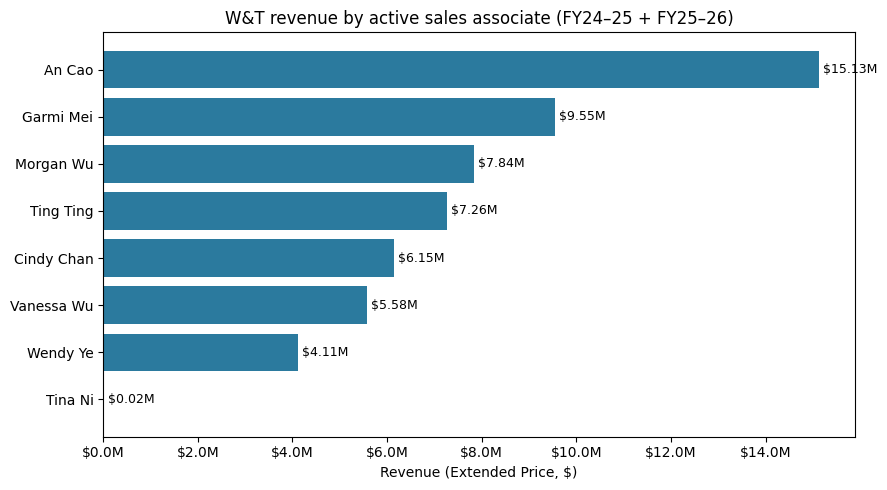

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
order = by_member.sort_values("Revenue")
ax.barh(order.index, order["Revenue"], color="#2b7a9e")
ax.set_title("W&T revenue by active sales associate (FY24–25 + FY25–26)")
ax.set_xlabel("Revenue (Extended Price, $)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
for y, v in enumerate(order["Revenue"]):
    ax.text(v, y, f" ${v/1e6:.2f}M", va="center", fontsize=9)
plt.tight_layout()
plt.show()

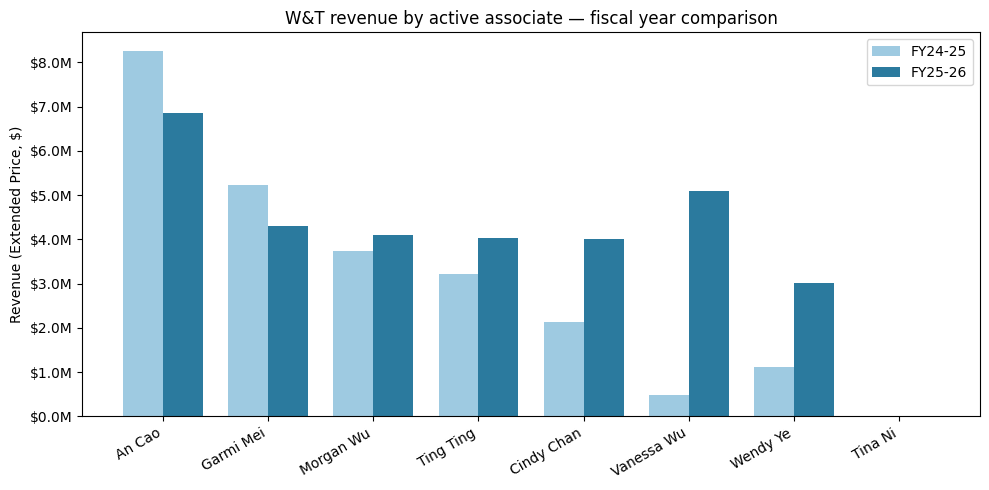

In [13]:
fy_cols = [c for c in ["FY24-25", "FY25-26"] if c in by_year.columns]
plot_df = by_year[fy_cols].loc[by_member.index]  # ordered by total revenue

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(plot_df))
w = 0.38
colors = {"FY24-25": "#9ecae1", "FY25-26": "#2b7a9e"}
for i, c in enumerate(fy_cols):
    ax.bar(x + (i - 0.5) * w, plot_df[c], w, label=c, color=colors.get(c))
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=30, ha="right")
ax.set_title("W&T revenue by active associate — fiscal year comparison")
ax.set_ylabel("Revenue (Extended Price, $)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"${y/1e6:.1f}M"))
ax.legend()
plt.tight_layout()
plt.show()

## 10. Findings & next steps

**What this notebook establishes**
- A reusable `resolve_batch()` attribution function mapping each invoice's batch
  number to a roster associate (prefix match + free-text `Other Names` fold-in).
- Revenue contributed by each **active** member, both combined and by fiscal
  year, with a full reconciliation so no invoice revenue is silently dropped.

**Caveats**
- Revenue here is gross **invoice** `Extended Price` (returns excluded per the
  agreed scope). Unmatched prefixes (`AC`, `JL`, `KS`, `SL`, `YU`, `DO NOT POST`)
  are excluded from associate totals — see the reconciliation table for their size.
- Attribution credits whoever is encoded in the batch number; it does not yet
  distinguish a desk owner from coverage.

**Suggested next steps toward a Coreline-style evaluation**
1. Resolve the larger unmatched buckets (e.g. `AC`) with the business — confirm
   whether they are a real associate, a house account, or non-sales activity.
2. Add **margin** (revenue − `Extended Cost`) for a profit-dollars view.
3. Move to **customer-level** attribution (book of accounts per associate) to
   support retention / growth / coverage analysis like Coreline.
4. Define self-comparison baselines (account vs its own prior period) rather
   than ranking associates on raw revenue, which largely reflects book size.